In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, PowerTransformer 
from sklearn.compose import ColumnTransformer
from imblearn.combine import SMOTETomek
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, matthews_corrcoef, f1_score
import pickle

In [2]:
df= pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [4]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [5]:
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [6]:
df.shape

(45000, 14)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.nunique()

person_age                           60
person_gender                         2
person_education                      5
person_income                     33989
person_emp_exp                       63
person_home_ownership                 4
loan_amnt                          4483
loan_intent                           6
loan_int_rate                      1302
loan_percent_income                  64
cb_person_cred_hist_length           29
credit_score                        340
previous_loan_defaults_on_file        2
loan_status                           2
dtype: int64

In [9]:
df['person_gender'].value_counts(normalize=True)*100

person_gender
male      55.202222
female    44.797778
Name: proportion, dtype: float64

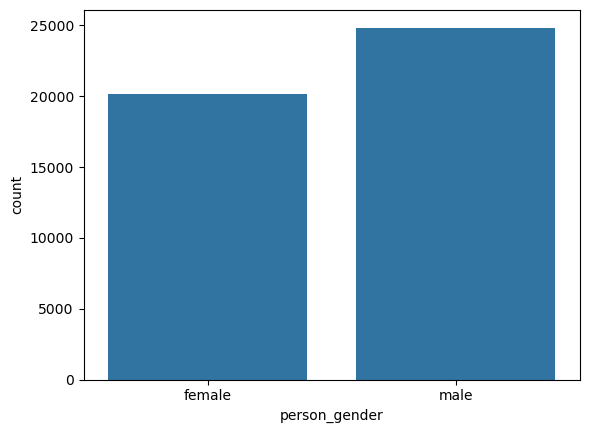

In [10]:
sns.countplot(df, x= 'person_gender');

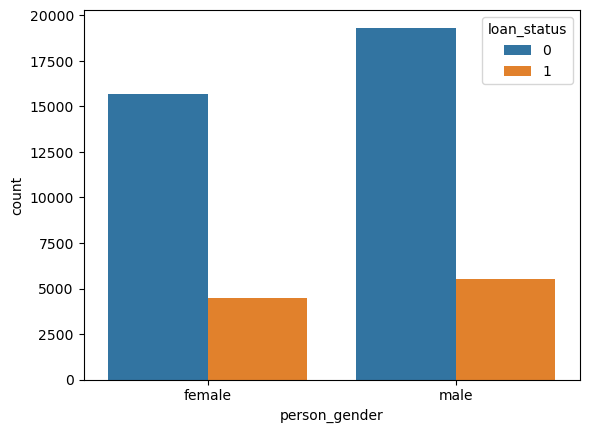

In [11]:
sns.countplot(df, x= 'person_gender', hue='loan_status');

In [12]:
df['person_education'].value_counts(normalize=True)*100

person_education
Bachelor       29.775556
Associate      26.728889
High School    26.604444
Master         15.511111
Doctorate       1.380000
Name: proportion, dtype: float64

<Axes: xlabel='person_education', ylabel='count'>

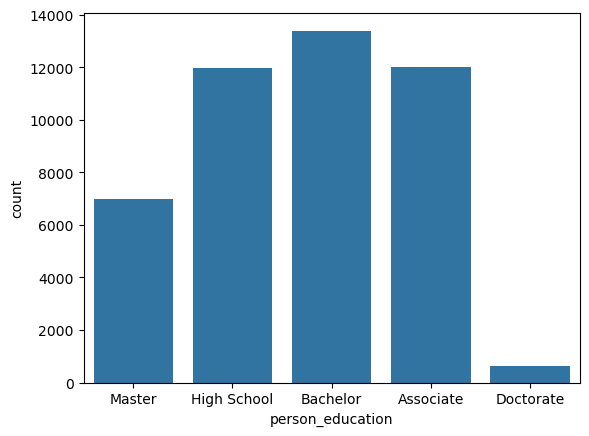

In [13]:
sns.countplot(df, x='person_education')

In [14]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [15]:
df['person_home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [16]:
df['person_home_ownership'].value_counts(normalize=True)*100

person_home_ownership
RENT        52.095556
MORTGAGE    41.086667
OWN          6.557778
OTHER        0.260000
Name: proportion, dtype: float64

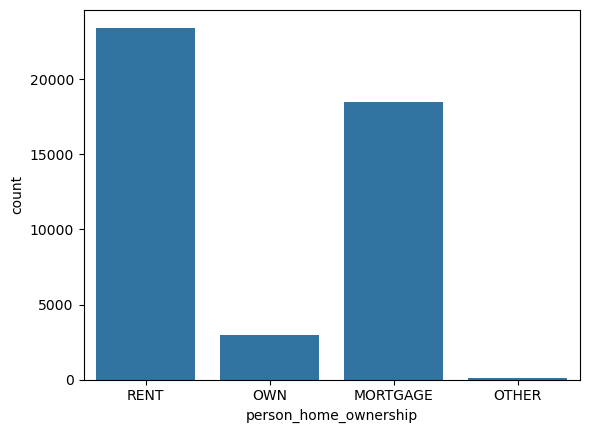

In [17]:
sns.countplot(df, x='person_home_ownership');

In [18]:
df['loan_intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [19]:
df['loan_intent'].value_counts(normalize=True)*100

loan_intent
EDUCATION            20.340000
MEDICAL              18.995556
VENTURE              17.375556
PERSONAL             16.782222
DEBTCONSOLIDATION    15.877778
HOMEIMPROVEMENT      10.628889
Name: proportion, dtype: float64

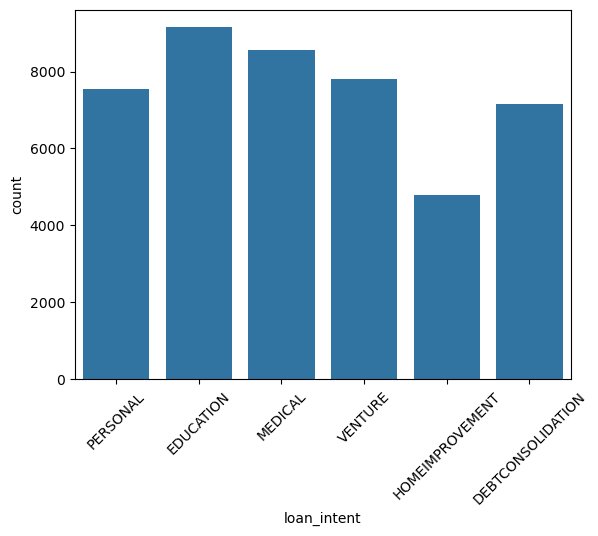

In [20]:
sns.countplot(df, x='loan_intent')
plt.xticks(rotation=45)
plt.show()

In [21]:
df['previous_loan_defaults_on_file'].value_counts(normalize=True)*100

previous_loan_defaults_on_file
Yes    50.795556
No     49.204444
Name: proportion, dtype: float64

In [22]:
df.select_dtypes('number').columns

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='object')

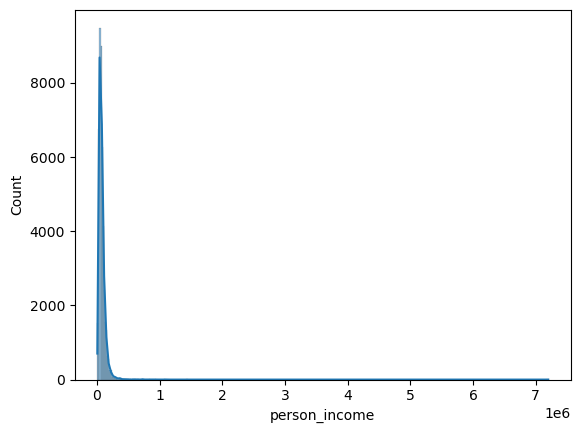

In [23]:
sns.histplot(df, x='person_income', kde=True);

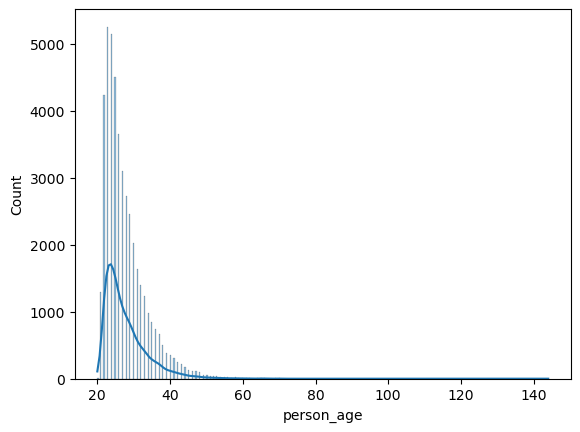

In [24]:
sns.histplot(df, x='person_age', kde=True);

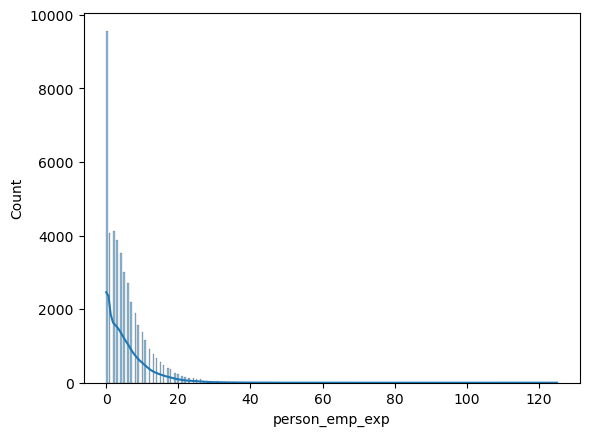

In [25]:
sns.histplot(df, x='person_emp_exp', kde=True);

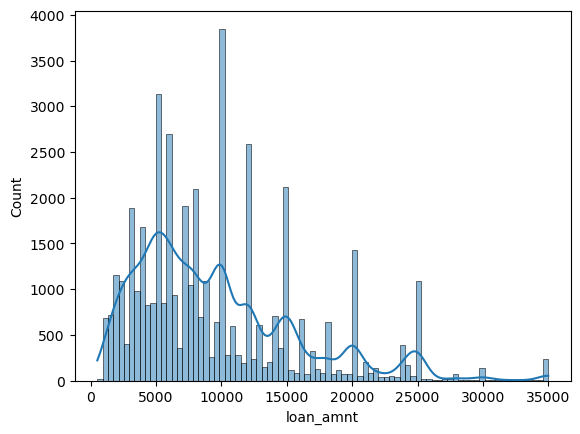

In [26]:
sns.histplot(df, x='loan_amnt', kde=True);

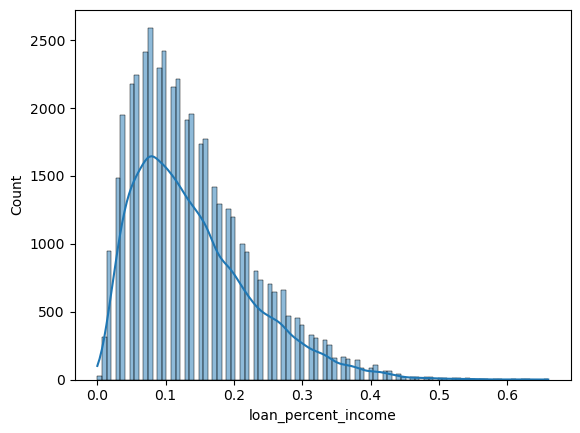

In [27]:
sns.histplot(df, x='loan_percent_income', kde=True);

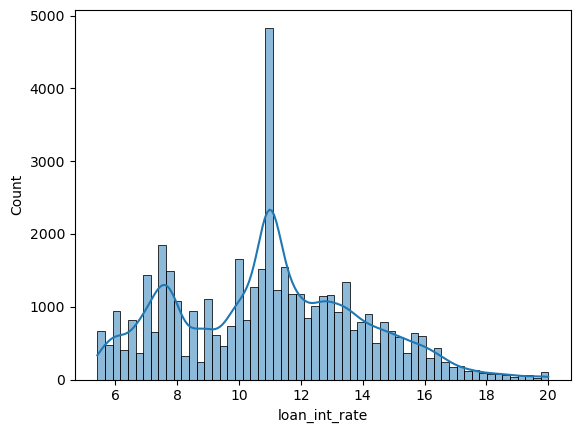

In [28]:
sns.histplot(df, x='loan_int_rate', kde=True);

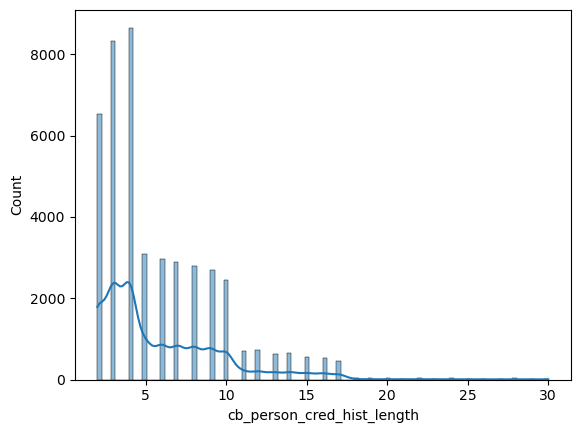

In [29]:
sns.histplot(df, x='cb_person_cred_hist_length', kde=True);

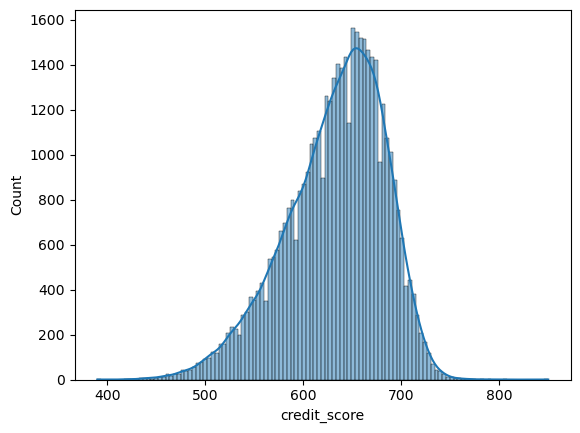

In [30]:
sns.histplot(df, x='credit_score', kde=True);

In [31]:
df['loan_status'].value_counts(normalize=True)*100

loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64

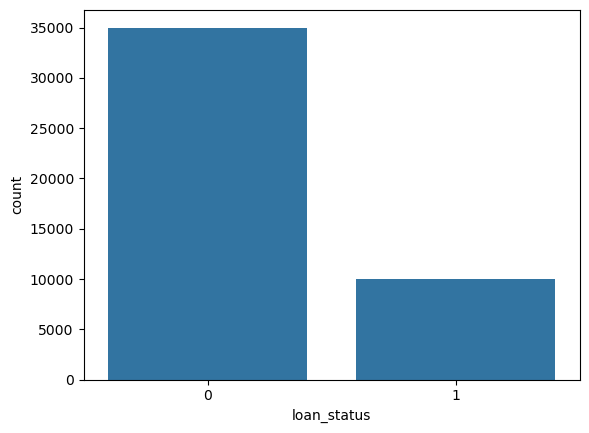

In [32]:
sns.countplot(df, x='loan_status');

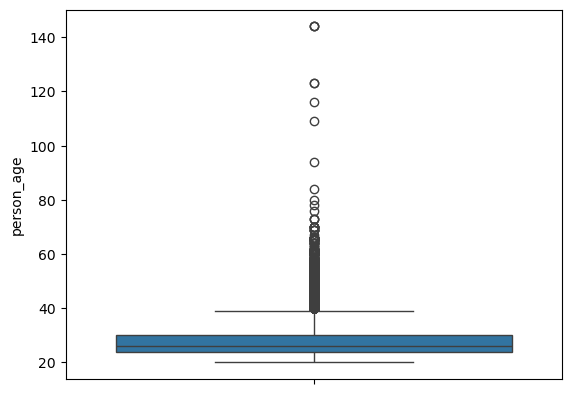

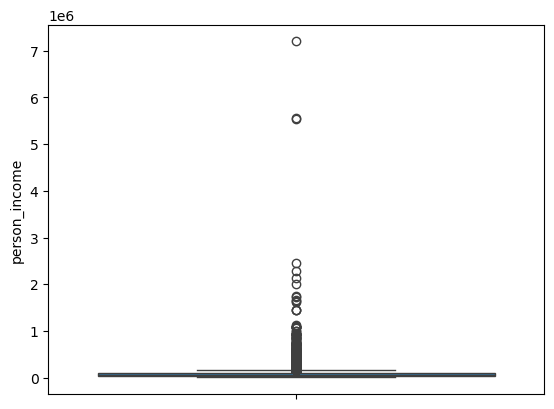

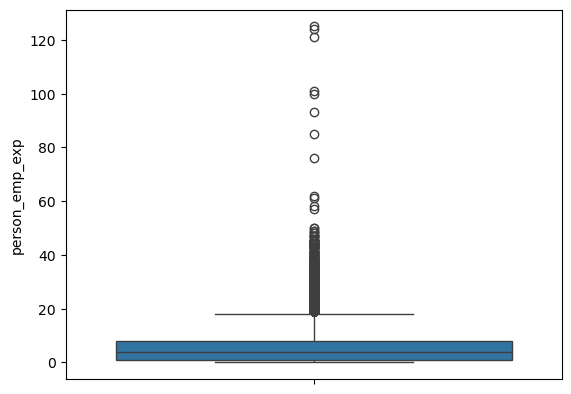

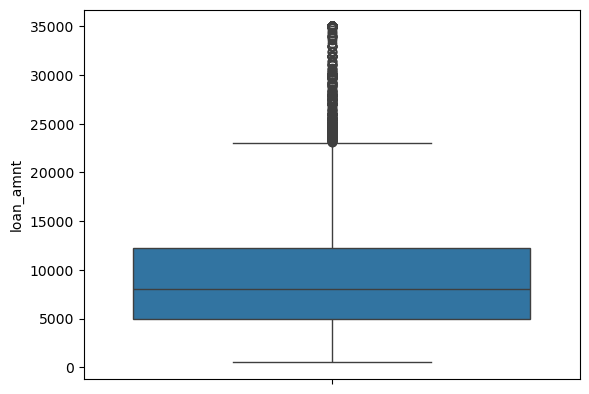

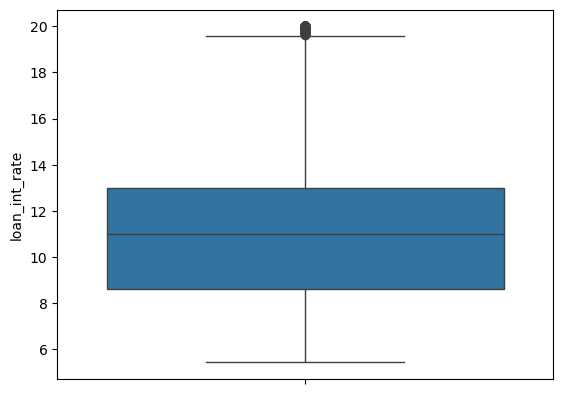

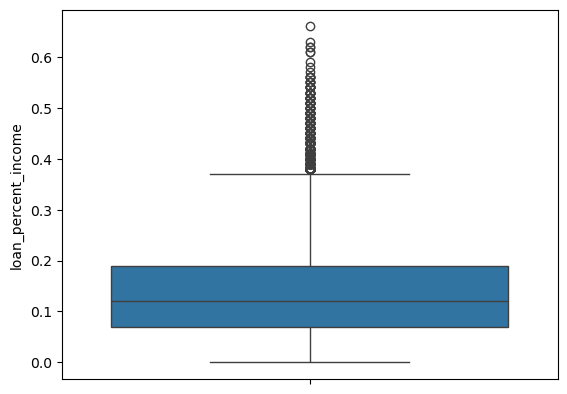

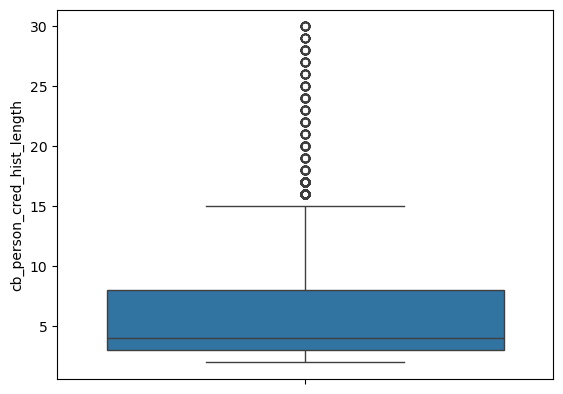

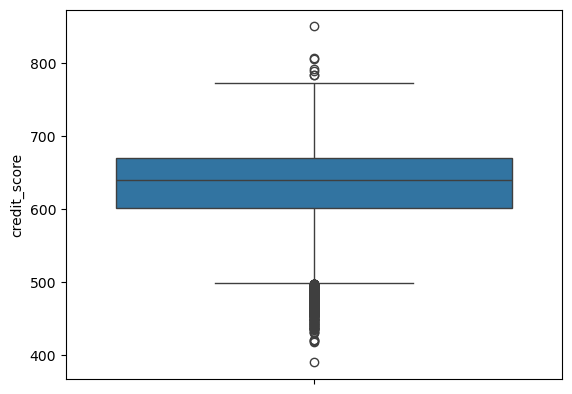

In [33]:
for col in df.select_dtypes('number').columns[:-1]:
    sns.boxplot(df[col])
    plt.show()

In [34]:
# The outliers are real data not error so I'll keep it 

In [35]:
df.select_dtypes('number').columns

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='object')

In [36]:
loan_stat_group= df.groupby('loan_status')

In [37]:
loan_stat_group['person_age'].mean()

loan_status
0    27.833571
1    27.521300
Name: person_age, dtype: float64

<Axes: title={'center': 'Average age by loan status'}, xlabel='loan_status'>

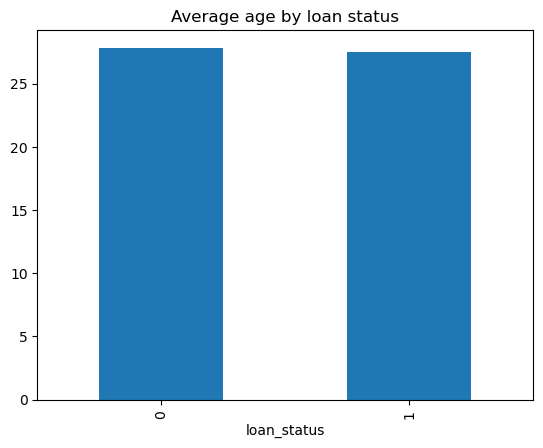

In [38]:
loan_stat_group['person_age'].mean().plot(kind='bar', title='Average age by loan status')

In [39]:
loan_stat_group['person_income'].mean()

loan_status
0    86157.040743
1    59886.096900
Name: person_income, dtype: float64

<Axes: title={'center': 'average income by loan status'}, xlabel='loan_status'>

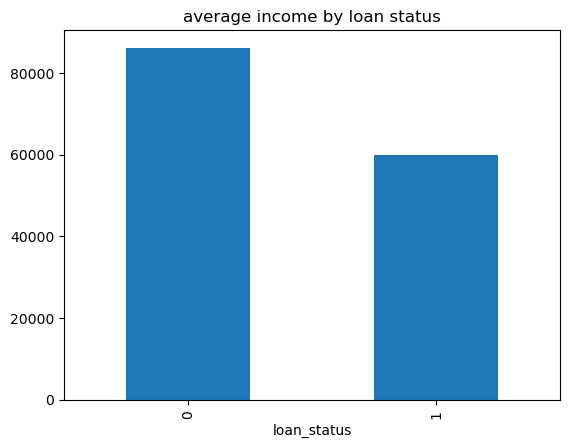

In [40]:
loan_stat_group['person_income'].mean().plot(kind='bar', title='average income by loan status', )

In [41]:
loan_stat_group['person_emp_exp'].mean()

loan_status
0    5.476714
1    5.178000
Name: person_emp_exp, dtype: float64

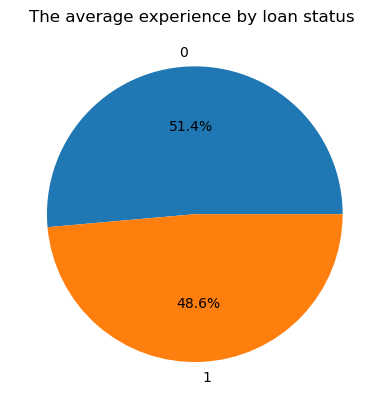

In [42]:
exp=loan_stat_group['person_emp_exp'].mean()
plt.pie(exp, labels= exp.index, autopct='%1.1f%%')
plt.title('The average experience by loan status ')
plt.show()

In [43]:
ln_amnt= loan_stat_group['loan_amnt'].mean()
ln_amnt

loan_status
0     9219.576914
1    10855.689800
Name: loan_amnt, dtype: float64

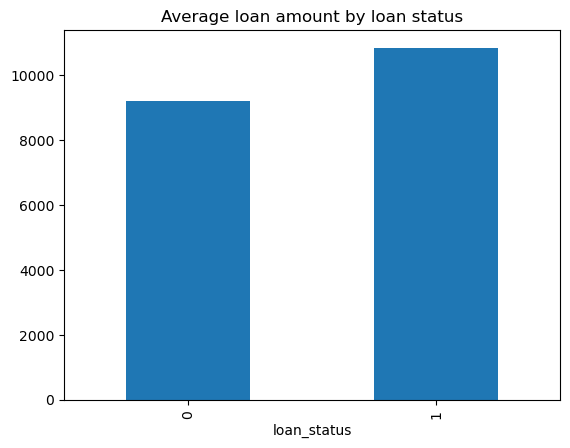

In [44]:
ln_amnt.plot(kind='bar', title='Average loan amount by loan status')
plt.show()

In [45]:
int_rate=loan_stat_group['loan_int_rate'].mean()
int_rate

loan_status
0    10.477981
1    12.856794
Name: loan_int_rate, dtype: float64

<Axes: title={'center': 'Average interest rate by loan status'}, xlabel='loan_status'>

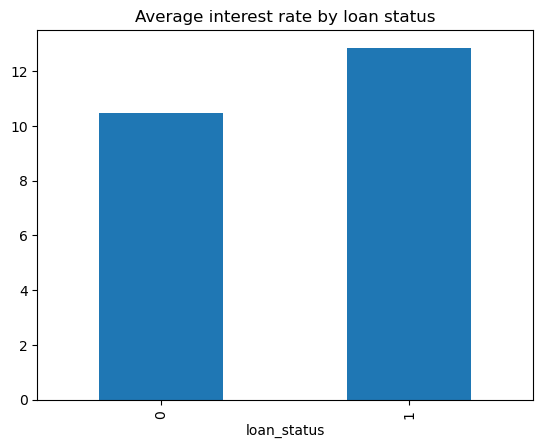

In [46]:
int_rate.plot(kind='bar', title='Average interest rate by loan status')

In [47]:
loan_stat_group['loan_percent_income'].mean()

loan_status
0    0.121783
1    0.202521
Name: loan_percent_income, dtype: float64

<Axes: title={'center': 'Average loan to income ratio by loan stat'}, xlabel='loan_status'>

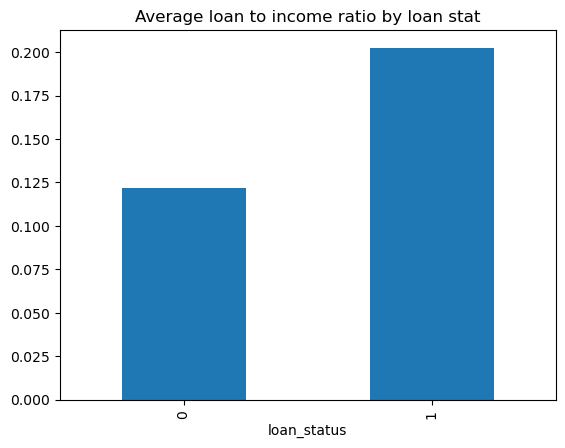

In [48]:
loan_stat_group['loan_percent_income'].mean().plot(kind='bar', title='Average loan to income ratio by loan stat')

In [49]:
loan_stat_group['cb_person_cred_hist_length'].mean()

loan_status
0    5.898286
1    5.759700
Name: cb_person_cred_hist_length, dtype: float64

<Axes: title={'center': 'Average credit history length by loan stat'}, xlabel='loan_status'>

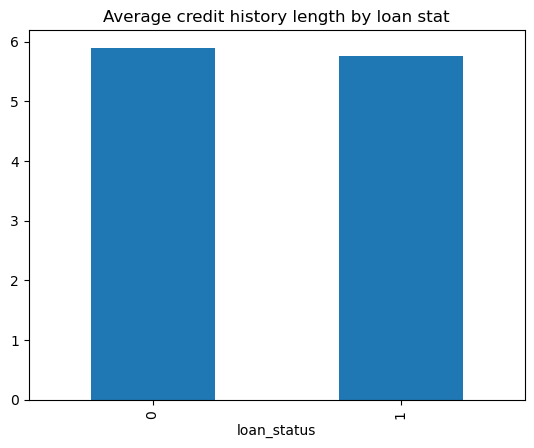

In [50]:
loan_stat_group['cb_person_cred_hist_length'].mean().plot(kind='bar', title='Average credit history length by loan stat')

In [51]:
loan_stat_group['credit_score'].mean()

loan_status
0    632.814914
1    631.887200
Name: credit_score, dtype: float64

<Axes: title={'center': 'Average credit score  ratio by loan stat'}, xlabel='loan_status'>

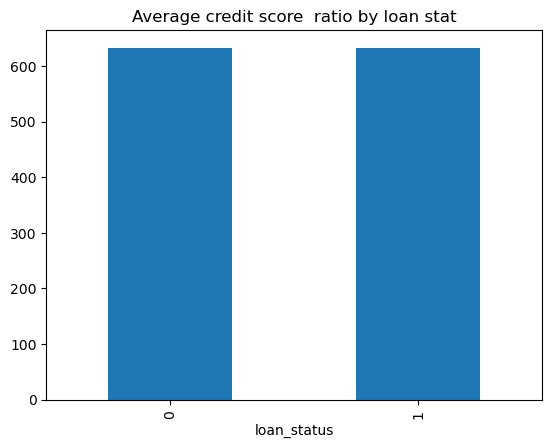

In [52]:
loan_stat_group['credit_score'].mean().plot(kind='bar', title='Average credit score  ratio by loan stat')

In [53]:
df.select_dtypes('object').columns

Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')

In [54]:
df.groupby('person_gender')['loan_status'].value_counts(normalize=True)*100

person_gender  loan_status
female         0              77.751873
               1              22.248127
male           0              77.798800
               1              22.201200
Name: proportion, dtype: float64

In [55]:
df.groupby('person_gender')['loan_status'].mean()

person_gender
female    0.222481
male      0.222012
Name: loan_status, dtype: float64

In [56]:
df.groupby('person_education')['loan_status'].mean()

person_education
Associate      0.220319
Bachelor       0.225241
Doctorate      0.228663
High School    0.223104
Master         0.217622
Name: loan_status, dtype: float64

In [57]:
df.groupby('person_home_ownership')['loan_status'].mean()

person_home_ownership
MORTGAGE    0.115961
OTHER       0.333333
OWN         0.075229
RENT        0.323977
Name: loan_status, dtype: float64

In [58]:
df.groupby('loan_intent')['loan_status'].mean()

loan_intent
DEBTCONSOLIDATION    0.302729
EDUCATION            0.169562
HOMEIMPROVEMENT      0.263015
MEDICAL              0.278194
PERSONAL             0.201404
VENTURE              0.144264
Name: loan_status, dtype: float64

In [59]:
df.groupby('previous_loan_defaults_on_file')['loan_status'].mean()

previous_loan_defaults_on_file
No     0.45163
Yes    0.00000
Name: loan_status, dtype: float64

In [60]:
df.select_dtypes('number').skew()

person_age                     2.548154
person_income                 34.137583
person_emp_exp                 2.594917
loan_amnt                      1.179731
loan_int_rate                  0.213784
loan_percent_income            1.034512
cb_person_cred_hist_length     1.631720
credit_score                  -0.610261
loan_status                    1.336351
dtype: float64

In [61]:
(df.select_dtypes('number').skew()).index

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='object')

In [62]:
df.select_dtypes('object').columns

Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')

In [63]:
label= LabelEncoder()
df['person_gender']= label.fit_transform(df['person_gender'])

In [64]:
order= [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]
ordencode= OrdinalEncoder(categories= order)
df['person_education']= ordencode.fit_transform(df[['person_education']])

In [65]:
df['person_home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [66]:
df['previous_loan_defaults_on_file']= label.fit_transform(df['previous_loan_defaults_on_file'])

In [67]:
# Encoding loan_intent and person_home_ownership
encode= pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'], dtype=int)
encod_df= pd.concat([df, encode], axis=1)

In [68]:
encod_df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status',
       'person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length', 'credit_score',
       'previous_loan_defaults_on_file', 'loan_status',
       'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE'],
      dtype='object')

In [69]:
encod_df.drop(columns=['person_home_ownership', 'loan_intent'], axis=1, inplace=True)
encod_df= encod_df.loc[:, ~(encod_df.columns.duplicated())]

In [70]:
encod_df.shape

(45000, 22)

In [71]:
x= encod_df.drop(columns=['loan_status'], axis=1)
y= encod_df['loan_status']

In [72]:
# flag everyone who's within top 5% loan to income percent 
# flags anyone whose annual income is 0
x['high_debt_flag']      = (x['loan_percent_income'] > x['loan_percent_income'].quantile(0.95)).astype(int)
x['zero_income_flag']    = (x['person_income'] == 0).astype(int)

In [73]:
# 20% for test and 80% for train 
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2,
                                                    random_state= 42,
                                                    stratify=y
                                                   )

In [74]:
encod_df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length', 'credit_score',
       'previous_loan_defaults_on_file', 'loan_status',
       'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE'],
      dtype='object')

In [75]:
x_train.skew()

person_age                         2.533045
person_gender                     -0.199437
person_education                   0.202306
person_income                     36.159082
person_emp_exp                     2.594476
loan_amnt                          1.176414
loan_int_rate                      0.207298
loan_percent_income                1.043264
cb_person_cred_hist_length         1.625431
credit_score                      -0.615153
previous_loan_defaults_on_file    -0.029227
person_home_ownership_MORTGAGE     0.360743
person_home_ownership_OTHER       19.187689
person_home_ownership_OWN          3.503446
person_home_ownership_RENT        -0.081181
loan_intent_DEBTCONSOLIDATION      1.858316
loan_intent_EDUCATION              1.479383
loan_intent_HOMEIMPROVEMENT        2.550881
loan_intent_MEDICAL                1.565385
loan_intent_PERSONAL               1.792422
loan_intent_VENTURE                1.729100
high_debt_flag                     4.369717
zero_income_flag                

In [76]:
outlier_features= ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score']

skewed_features= [ col for col in x_train.skew()[x_train.skew()>=0.1].index]

In [77]:
preprocessor = ColumnTransformer(transformers=[
    ('robust', RobustScaler(),                         outlier_features),
    ('power',  PowerTransformer(method='yeo-johnson'), skewed_features),
],
    remainder='passthrough'
)

In [78]:
linear_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    
}

In [79]:
tree_based_models= {
    'Random Forest':       RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(scale_pos_weight=3, random_state=42, eval_metric='aucpr', verbosity=0),
    'LightGBM':            LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
}

In [80]:
results   = []
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [81]:
for model_name, model in linear_models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),                        
        ('selector',     SelectKBest(                           
                            mutual_info_classif, k=20)),         
        ('model',        model)                                 
    ])

    cv_scores = cross_val_score(
        pipeline, x_train, y_train,
        cv=cv,
        scoring='roc_auc'
    )

    pipeline.fit(x_train, y_train)
    y_pred      = pipeline.predict(x_test)
    y_pred_prob = pipeline.predict_proba(x_test)[:, 1]

    results.append({
        'Model':      model_name,
        'ROC-AUC':    round(roc_auc_score(y_test, y_pred_prob), 4),
        'F1 Score':   round(f1_score(y_test, y_pred), 4),
        'MCC':        round(matthews_corrcoef(y_test, y_pred), 4),
        'CV ROC-AUC': round(cv_scores.mean(), 4),
        'CV Std':     round(cv_scores.std(), 4)
    })
    print(f"\n{'─' * 70}")
    print(f"  {model_name}")
    print(f"{'─' * 70}")
    print(classification_report(y_test, y_pred, target_names=['Not Worthy', 'Worthy']))



──────────────────────────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Not Worthy       0.97      0.85      0.91      7000
      Worthy       0.64      0.92      0.75      2000

    accuracy                           0.87      9000
   macro avg       0.81      0.89      0.83      9000
weighted avg       0.90      0.87      0.87      9000



In [82]:
for model_name, model in tree_based_models.items():

    pipeline = Pipeline([                              
        ('model',        model)                                 
    ])

    cv_scores = cross_val_score(
        pipeline, x_train, y_train,
        cv=cv,
        scoring='roc_auc'
    )

    pipeline.fit(x_train, y_train)
    y_pred      = pipeline.predict(x_test)
    y_pred_prob = pipeline.predict_proba(x_test)[:, 1]

    results.append({
        'Model':      model_name,
        'ROC-AUC':    round(roc_auc_score(y_test, y_pred_prob), 4),
        'F1 Score':   round(f1_score(y_test, y_pred), 4),
        'MCC':        round(matthews_corrcoef(y_test, y_pred), 4),
        'CV ROC-AUC': round(cv_scores.mean(), 4),
        'CV Std':     round(cv_scores.std(), 4)
    })
    print(f"\n{'─' * 70}")
    print(f"  {model_name}")
    print(f"{'─' * 70}")
    print(classification_report(y_test, y_pred, target_names=['Not Worthy', 'Worthy']))



──────────────────────────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Not Worthy       0.93      0.98      0.95      7000
      Worthy       0.90      0.75      0.82      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000


──────────────────────────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Not Worthy       0.97      0.94      0.95      7000
      Worthy       0.80      0.89      0.84      2000

    accuracy                           0.92      9000
   macro avg       0.88      0.91      0.89      9000
weighted avg       0.93      0.92      0.93      9000


─────────────────────────────────

In [83]:
#── 8. SUMMARY TABLE ──────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SUMMARY — RANKED BY ROC-AUC")
print("=" * 70)
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df)
print(f"\n✅ Best Model: {results_df.iloc[0]['Model']}")



SUMMARY — RANKED BY ROC-AUC
                 Model  ROC-AUC  F1 Score     MCC  CV ROC-AUC  CV Std
2              XGBoost   0.9785    0.8379  0.7902      0.9774  0.0012
3             LightGBM   0.9778    0.8168  0.7651      0.9767  0.0018
1        Random Forest   0.9748    0.8223  0.7823      0.9730  0.0019
0  Logistic Regression   0.9573    0.7538  0.6873      0.9568  0.0019

✅ Best Model: XGBoost


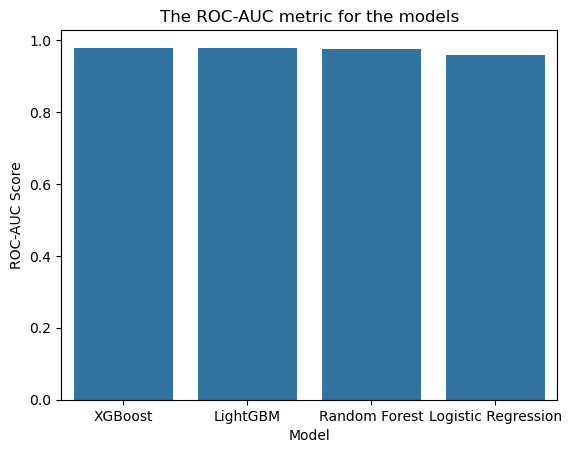

In [84]:
sns.barplot(data= results_df, x= 'Model', y= 'ROC-AUC')
plt.ylabel('ROC-AUC Score')
plt.title('The ROC-AUC metric for the models')
plt.savefig('ROC-AUC score.png')
plt.show()

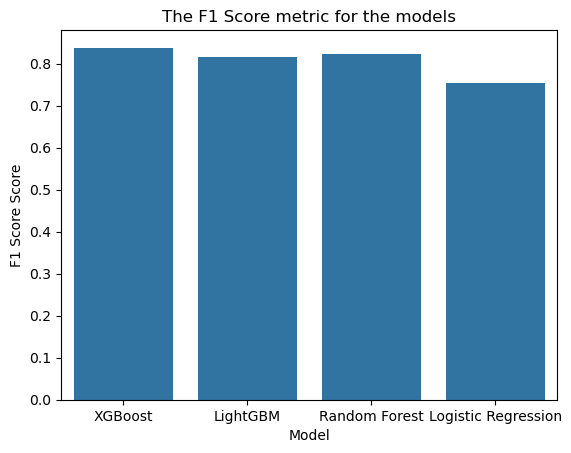

In [85]:
sns.barplot(data= results_df, x= 'Model', y= 'F1 Score')
plt.ylabel('F1 Score Score')
plt.title('The F1 Score metric for the models')
plt.savefig('F1 score.png')
plt.show()

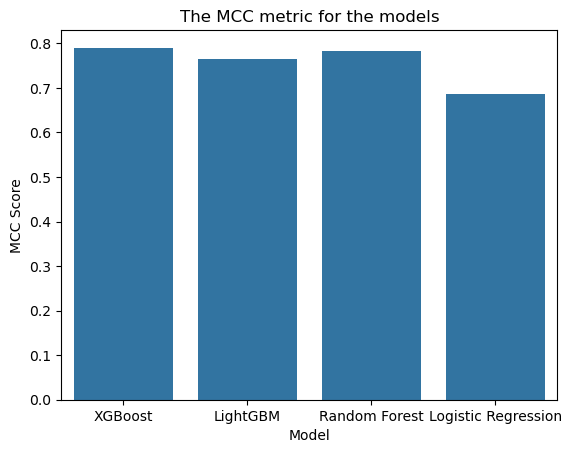

In [86]:
sns.barplot(data= results_df, x= 'Model', y= 'MCC')
plt.ylabel('MCC Score')
plt.title('The MCC metric for the models')
plt.savefig('MCC score.png')
plt.show()

In [87]:
best_pipeline = Pipeline([
    ('model', XGBClassifier(
        scale_pos_weight=3,
        random_state=42,
        eval_metric='aucpr',
        verbosity=0
    ))
])

best_pipeline.fit(x_train, y_train)

# Confirming the quality of the model 
y_pred      = best_pipeline.predict(x_test)
y_pred_prob = best_pipeline.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not Worthy', 'Worthy']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"MCC:     {matthews_corrcoef(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

  Not Worthy       0.97      0.94      0.95      7000
      Worthy       0.80      0.89      0.84      2000

    accuracy                           0.92      9000
   macro avg       0.88      0.91      0.89      9000
weighted avg       0.93      0.92      0.93      9000

ROC-AUC: 0.9785
MCC:     0.7902


In [88]:
# Saving the model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f, protocol=4)